In [1]:
import sys, pandas
print(sys.executable)

c:\Users\USER\Bitget-Report-2\.venv\Scripts\python.exe


In [5]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import numpy as np
import math
import nbformat

import plotly.io._renderers as _pr
_pr.nbformat = nbformat

In [ ]:
from plotting_utils import DEFAULT_THEME, update_timeseries_layout, add_watermark

# ── 1. Load Bitget tokenised XAUUSDT (24/7, already UTC) ──────────────────
bitget_xau = pd.read_csv(r"data\bitget_XAUUSDT_rwa_perpetual_1m_index_px.csv")
bitget_xau["datetime"] = pd.to_datetime(bitget_xau["datetime"], utc=True)
bitget_xau = bitget_xau.set_index("datetime").sort_index()[["close"]].rename(columns={"close": "Bitget XAUUSDT"})

# ── 2. Load Bitget tokenised XAGUSDT (24/7, already UTC) ──────────────────
bitget_xag = pd.read_csv(r"data\bitget_XAGUSDT_rwa_perpetual_1m_index_px.csv")
bitget_xag["datetime"] = pd.to_datetime(bitget_xag["datetime"], utc=True)
bitget_xag = bitget_xag.set_index("datetime").sort_index()[["close"]].rename(columns={"close": "Bitget XAGUSDT"})

# ── 3. Load Bloomberg XAU + XAG spot (traditional market hours) ───────────
bbg = pd.read_excel("data/gold silver.xlsx", sheet_name="Sheet1")
bbg["Date"] = pd.to_datetime(bbg["Date"]).dt.tz_localize("UTC")
bbg = bbg.set_index("Date").sort_index()
bbg = bbg.rename(columns={
    "XAU BGN Curncy  (R1)": "Bloomberg XAU (Spot)",
    "XAG BGN Curncy  (L1)": "Bloomberg XAG (Spot)",
})

# ── 5. Merge on datetime index ────────────────────────────────────────────
merged_xau = bitget_xau.join(bbg, how="outer")
merged_xag = bitget_xag.join(bbg, how="outer")

# ── 6. Window: Fri 27 Feb 18:00 → Mon 2 Mar 12:00 UTC ────────────────────
window_start = "2026-02-27 18:00"
window_end   = "2026-03-02 12:00"

plot_df_xau = merged_xau.loc[window_start:window_end]
plot_df_xag = merged_xag.loc[window_start:window_end]

# Keep legacy names so downstream gold cells still work
bitget   = bitget_xau
#bitget_5m = bitget_xau_5m
#bbg_5m    = bbg_xau_5m
merged    = merged_xau
plot_df   = plot_df_xau

print("=== GOLD ===")
print(f"  Bitget points : {plot_df_xau['Bitget XAUUSDT'].notna().sum()}")
print(f"  Bloomberg pts : {plot_df_xau['Bloomberg XAU (Spot)'].notna().sum()}")
print("\n=== SILVER ===")
print(f"  Bitget points : {plot_df_xag['Bitget XAGUSDT'].notna().sum()}")
print(f"  Bloomberg pts : {plot_df_xag['Bloomberg XAG (Spot)'].notna().sum()}")

=== GOLD ===
  Bitget points : 3961
  Bloomberg pts : 1021

=== SILVER ===
  Bitget points : 3961
  Bloomberg pts : 1021


In [13]:
# ── Price-discovery chart: Bitget XAUUSDT vs Bloomberg XAU Spot ────────────

announcement_time = pd.Timestamp("2026-02-28 07:30", tz="UTC")

# Colours
BITGET_COLOR = "#00E5A0"   # Bitget brand green
BBG_COLOR    = "#FFD700"   # gold for Bloomberg spot

fig = go.Figure()

# Bloomberg XAU spot (will have a gap over the weekend)
fig.add_trace(go.Scatter(
    x=plot_df.index,
    y=plot_df["Bloomberg XAU (Spot)"],
    name="Bloomberg XAU Spot",
    mode="lines",
    line=dict(color=BBG_COLOR, width=2),
    connectgaps=False,          # ← keeps the weekend gap visible
))

# Bitget XAUUSDT 24/7
fig.add_trace(go.Scatter(
    x=plot_df.index,
    y=plot_df["Bitget XAUUSDT"],
    name="Bitget XAUUSDT (24/7)",
    mode="lines",
    line=dict(color=BITGET_COLOR, width=2),
    connectgaps=False,
))

# ── Annotation: airstrike announcement ────────────────────────────────────
fig.add_vline(
    x=announcement_time.timestamp() * 1000,   # plotly expects ms
    line_width=1.5, line_dash="dash", line_color="red",
)
fig.add_annotation(
    x=announcement_time,
    y=plot_df["Bitget XAUUSDT"].max() * 1.002,
    text="Trump announces<br>Iran airstrikes<br>Sat 28 Feb 07:30 UTC",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="white", size=12),
    bgcolor="rgba(180,0,0,0.55)",
    bordercolor="red",
    borderwidth=1,
    ax=80, ay=-40,
)

# ── Shaded region for traditional-market closure ──────────────────────────
trad_close = pd.Timestamp("2026-02-27 22:00", tz="UTC")
trad_open  = pd.Timestamp("2026-03-01 23:00", tz="UTC")

fig.add_vrect(
    x0=trad_close, x1=trad_open,
    fillcolor="rgba(255,255,255,0.06)",
    line_width=0,
)
fig.add_annotation(
    x=trad_close + (trad_open - trad_close) / 2,
    y=1.0, yref="paper",
    text="Traditional markets closed",
    showarrow=False,
    font=dict(color="white", size=11),
)

# ── Layout ────────────────────────────────────────────────────────────────
update_timeseries_layout(fig)

fig.update_layout(
    yaxis_title="Price",
    yaxis_tickprefix="$",
    xaxis=dict(
        tickformat="%a %d %b\n%H:%M UTC",
        dtick=6 * 3600 * 1000,          # tick every 6 hours
    ),
)

add_watermark(fig)
fig

In [15]:
# ── Price-discovery chart: Bitget XAGUSDT vs Bloomberg XAG Spot ────────────

BITGET_SILVER_COLOR = ""   # Bitget brand green
BBG_SILVER_COLOR    = "white"   # silver for Bloomberg spot

fig_ag = go.Figure()

# Bloomberg XAG spot (gap over the weekend)
fig_ag.add_trace(go.Scatter(
    x=plot_df_xag.index,
    y=plot_df_xag["Bloomberg XAG (Spot)"],
    name="XAG (Silver) Spot Price",
    mode="lines",
    line=dict(color=BBG_SILVER_COLOR, width=2.5),
    connectgaps=False,
))

# Bitget XAGUSDT 24/7
fig_ag.add_trace(go.Scatter(
    x=plot_df_xag.index,
    y=plot_df_xag["Bitget XAGUSDT"],
    name="Bitget XAGUSDT (Tokenised)",
    mode="lines",
    line=dict(width=2),
    connectgaps=False,
))

# ── Annotation: airstrike announcement ────────────────────────────────────
fig_ag.add_vline(
    x=announcement_time.timestamp() * 1000,
    line_width=1.5, line_dash="dash", line_color="white",
)
fig_ag.add_annotation(
    x=announcement_time,
    y=plot_df_xag["Bitget XAGUSDT"].max() * 1.002,
    text="Trump announces<br>Iran airstrikes<br>Sat 28 Feb 07:30 UTC",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="white", size=12),
    bgcolor="rgba(180,0,0,0.55)",
    bordercolor="red",
    borderwidth=1,
    ax=80, ay=-40,
)

# ── Shaded region for traditional-market closure ──────────────────────────
fig_ag.add_vrect(
    x0=trad_close, x1=trad_open,
    fillcolor="rgba(255,255,255,0.06)",
    line_width=0,
)
fig_ag.add_annotation(
    x=trad_close + (trad_open - trad_close) / 2,
    y=1.0, yref="paper",
    text="Traditional markets closed",
    showarrow=False,
    font=dict(color="white", size=11),
)

# ── Layout ────────────────────────────────────────────────────────────────
update_timeseries_layout(fig_ag)

fig_ag.update_layout(
    yaxis_title="Price",
    yaxis_tickprefix="$",
    xaxis=dict(
        tickformat="%a %d %b\n%H:%M UTC",
        dtick=6 * 3600 * 1000,
    ),
)

add_watermark(fig_ag)
fig_ag

In [16]:
# ── Price discovery timeline ──────────────────────────────────────────────
# 1. Where did Bloomberg close on Friday?
bbg_fri_close = bbg.loc[:"2026-02-28 00:00", "Bloomberg XAU (Spot)"].dropna().iloc[-1]
bbg_fri_close_time = bbg.loc[:"2026-02-28 00:00", "Bloomberg XAU (Spot)"].dropna().index[-1]

# 2. Where was Bitget when the airstrike was announced (Sat 07:30)?
bitget_at_announce = bitget.loc["2026-02-28 07:30":"2026-02-28 07:35"].iloc[0]["Bitget XAUUSDT"]

# 3. Where did Bloomberg reopen on Sunday?
bbg_sun_open = bbg.loc["2026-03-01 22:00":, "Bloomberg XAU (Spot)"].dropna().iloc[0]
bbg_sun_open_time = bbg.loc["2026-03-01 22:00":, "Bloomberg XAU (Spot)"].dropna().index[0]

# 4. Where was Bitget at the exact moment Bloomberg reopened?
bitget_at_bbg_open = bitget.loc[:bbg_sun_open_time].iloc[-1]["Bitget XAUUSDT"]

# 5. Bitget peak over the weekend
bitget_weekend = bitget.loc["2026-02-28":"2026-03-01 23:00"]
bitget_peak = bitget_weekend["Bitget XAUUSDT"].max()
bitget_peak_time = bitget_weekend["Bitget XAUUSDT"].idxmax()

print("=== PRICE DISCOVERY TIMELINE ===\n")
print(f"Fri 27 Feb  — Bloomberg closes at:    ${bbg_fri_close:,.2f}  ({bbg_fri_close_time.strftime('%H:%M UTC')})")
print(f"Sat 28 Feb  — Airstrike announced:     Bitget at ${bitget_at_announce:,.2f}  (07:30 UTC)")
print(f"              Bitget weekend peak:      ${bitget_peak:,.2f}  ({bitget_peak_time.strftime('%a %H:%M UTC')})")
print(f"Sun 01 Mar  — Bloomberg reopens at:    ${bbg_sun_open:,.2f}  ({bbg_sun_open_time.strftime('%H:%M UTC')})")
print(f"              Bitget at that moment:    ${bitget_at_bbg_open:,.2f}")
print()
print(f"Bloomberg weekend gap:          ${bbg_sun_open - bbg_fri_close:+,.2f}  ({(bbg_sun_open/bbg_fri_close - 1)*100:+.2f}%)")
print(f"Bitget already moved:           ${bitget_at_bbg_open - bbg_fri_close:+,.2f}  ({(bitget_at_bbg_open/bbg_fri_close - 1)*100:+.2f}%)")
print(f"Convergence gap at reopen:      ${bbg_sun_open - bitget_at_bbg_open:+,.2f}  ({(bbg_sun_open/bitget_at_bbg_open - 1)*100:+.2f}%)")

=== PRICE DISCOVERY TIMELINE ===

Fri 27 Feb  — Bloomberg closes at:    $5,278.93  (21:59 UTC)
Sat 28 Feb  — Airstrike announced:     Bitget at $5,308.87  (07:30 UTC)
              Bitget weekend peak:      $5,402.00  (Sat 10:13 UTC)
Sun 01 Mar  — Bloomberg reopens at:    $5,315.37  (23:00 UTC)
              Bitget at that moment:    $5,328.66

Bloomberg weekend gap:          $+36.44  (+0.69%)
Bitget already moved:           $+49.73  (+0.94%)
Convergence gap at reopen:      $-13.29  (-0.25%)


In [17]:
# ── 1) Load Maduro-specific Bitget XAU file (1m) ───────────────────────────
xau_maduro = pd.read_csv(
    r"data\bitget_XAUUSDT_maduro__perpetual_1m_20260102_20260106.csv"
)
xau_maduro["datetime_utc"] = pd.to_datetime(xau_maduro["datetime_utc"], utc=True)

xau_maduro = (
    xau_maduro
    .set_index("datetime_utc")
    .sort_index()[["close"]]
    .rename(columns={"close": "Bitget XAUUSDT"})
)

# ── 2) Load Bloomberg gold spot ─────────────────────────────────────────────
bbg = pd.read_excel("data/gold-maduro.xlsx", sheet_name="Sheet2")
bbg["Date"] = pd.to_datetime(bbg["Date"]).dt.tz_localize("UTC")
bbg = bbg.set_index("Date").sort_index()

bbg_xau = bbg[["Close"]].rename(
    columns={"Close": "Bloomberg XAU (Spot)"}
)

# ── 3) Merge (minute-level, no resample) ───────────────────────────────────
merged_xau_maduro = xau_maduro.join(bbg_xau, how="outer")

# optional event window
maduro_window_start = "2026-01-02 18:00"
maduro_window_end   = "2026-01-06 12:00"
plot_df_xau_maduro = merged_xau_maduro.loc[maduro_window_start:maduro_window_end].copy()

print("=== MADURO XAU MERGE ===")
print(f"Bitget points    : {plot_df_xau_maduro['Bitget XAUUSDT'].notna().sum()}")
print(f"Bloomberg points : {plot_df_xau_maduro['Bloomberg XAU (Spot)'].notna().sum()}")

=== MADURO XAU MERGE ===
Bitget points    : 3121
Bloomberg points : 2401


In [24]:
# ── Price-discovery chart: Bitget XAUUSDT vs Bloomberg XAU Spot (MADURO) ───

maduro_announcement_time = pd.Timestamp("2026-01-03 06:01", tz="UTC")  # edit if needed

# Colours
BITGET_COLOR = "#00E5A0"   # Bitget brand green
BBG_COLOR    = "#FFD700"   # gold for Bloomberg spot

fig_maduro = go.Figure()

# Bloomberg XAU spot (gap over weekend/closed hours remains visible)
fig_maduro.add_trace(go.Scatter(
    x=plot_df_xau_maduro.index,
    y=plot_df_xau_maduro["Bloomberg XAU (Spot)"],
    name="Bloomberg XAU Spot",
    mode="lines",
    line=dict(color=BBG_COLOR, width=2),
    connectgaps=False,
))

# Bitget XAUUSDT 24/7
fig_maduro.add_trace(go.Scatter(
    x=plot_df_xau_maduro.index,
    y=plot_df_xau_maduro["Bitget XAUUSDT"],
    name="Bitget XAUUSDT (24/7)",
    mode="lines",
    line=dict(color=BITGET_COLOR, width=2),
    connectgaps=False,
))

# ── Annotation: Maduro event headline ───────────────────────────────────────
fig_maduro.add_vline(
    x=maduro_announcement_time.timestamp() * 1000,  # plotly expects ms
    line_width=1.5, line_dash="dash", line_color="red",
)
fig_maduro.add_annotation(
    x=maduro_announcement_time,
    y=plot_df_xau_maduro["Bitget XAUUSDT"].max() * 1.002,
    text="US Military Strike in Venezuela<br>Sat 03 Jan 07:30 UTC",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="white", size=12),
    bgcolor="rgba(180,0,0,0.55)",
    bordercolor="red",
    borderwidth=1,
    ax=80, ay=-40,
)

# ── Shaded region for traditional-market closure ────────────────────────────
maduro_trad_close = pd.Timestamp("2026-01-02 22:00", tz="UTC")
maduro_trad_open  = pd.Timestamp("2026-01-04 23:00", tz="UTC")

fig_maduro.add_vrect(
    x0=maduro_trad_close, x1=maduro_trad_open,
    fillcolor="rgba(255,255,255,0.06)",
    line_width=0,
)
fig_maduro.add_annotation(
    x=maduro_trad_close + (maduro_trad_open - maduro_trad_close) / 1.8,
    y=1.0, yref="paper",
    text="Traditional markets closed",
    showarrow=False,
    font=dict(color="white", size=11),
)

# ── Layout ───────────────────────────────────────────────────────────────────
update_timeseries_layout(fig_maduro)

fig_maduro.update_layout(
    yaxis_title="Price",
    yaxis_tickprefix="$",
    xaxis=dict(
        tickformat="%a %d %b\n%H:%M UTC",
        dtick=6 * 3600 * 1000,
    ),
)

add_watermark(fig_maduro)
fig_maduro


In [25]:
# ── Load BTC hourly price from Block Scholes JSON ─────────────────────────
import json

btc_json_path = r"C:\Users\USER\DataGrabber\datagrabber\data\source_data_20260304_122714.json"

with open(btc_json_path) as f:
    raw = json.load(f)

btc_raw = pd.DataFrame(raw)
btc_raw["timestamp"] = pd.to_datetime(btc_raw["timestamp"], unit="ns")

# Filter to BTC spot price only
btc = (
    btc_raw[btc_raw["qualified_name"] == "blockscholes.spot.BTC_USD.1h.index.px"]
    [["timestamp", "px"]]
    .rename(columns={"px": "BTC", "timestamp": "datetime"})
    .copy()
)
btc["datetime"] = btc["datetime"].dt.tz_localize("UTC")
btc = btc.set_index("datetime").sort_index()

print(f"BTC hourly: {len(btc)} rows, {btc.index.min()} → {btc.index.max()}")
print(btc.tail(3))

BTC hourly: 47880 rows, 2020-09-16 02:00:00+00:00 → 2026-03-04 12:00:00+00:00
                                    BTC
datetime                               
2026-03-04 10:00:00+00:00  71518.849123
2026-03-04 11:00:00+00:00  71326.881511
2026-03-04 12:00:00+00:00  71113.117863


In [35]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 9.1 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.1 MB 9.1 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 9.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 9.0 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   --------------------------- ------------ 1.6/2.3 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------- -------------------------------- 1.3/7.0 MB 7.5 MB/s eta 


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


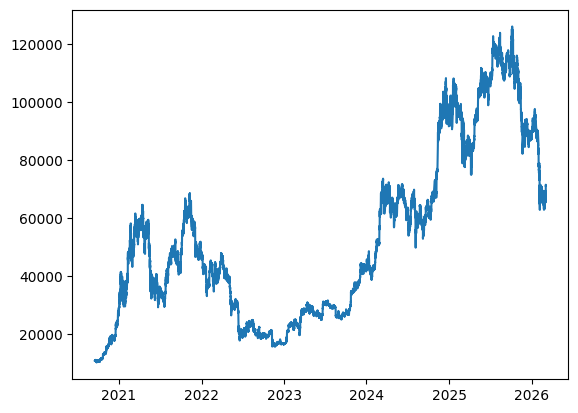

In [42]:
import matplotlib.pyplot as plt
plt.plot(btc.index, btc["BTC"])

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Hypothesis test: During Maduro capture (Jan), did traders hedge via BTC?
#                  During Iran airstrikes (Feb), did they go direct to gold?
# ══════════════════════════════════════════════════════════════════════════

# ── 1) Extract BTC for both event windows ─────────────────────────────────
# Maduro weekend: Fri 2 Jan 00:00 → Tue 6 Jan 00:00
btc_maduro = btc.loc["2026-01-02 00:00":"2026-01-06 00:00"].copy()

# Iran weekend: Fri 27 Feb 00:00 → Mon 2 Mar 00:00
btc_iran = btc.loc["2026-02-27 00:00":"2026-03-02 00:00"].copy()

# ── 2) Get Bitget XAUUSDT at 1h for fair comparison with hourly BTC ──────
xau_maduro_1h = xau_maduro.resample("1h").last().dropna()
xau_iran_1h   = bitget_xau.resample("1h").last().dropna()

xau_maduro_1h_window = xau_maduro_1h.loc["2026-01-02 00:00":"2026-01-06 00:00"]
xau_iran_1h_window   = xau_iran_1h.loc["2026-02-27 00:00":"2026-03-02 00:00"]

# ── 3) Normalise everything to 100 at window start ───────────────────────
def normalise(series):
    return (series / series.iloc[0]) * 100

btc_maduro_norm = normalise(btc_maduro["BTC"])
xau_maduro_norm = normalise(xau_maduro_1h_window["Bitget XAUUSDT"])

btc_iran_norm   = normalise(btc_iran["BTC"])
xau_iran_norm   = normalise(xau_iran_1h_window["Bitget XAUUSDT"])

# ── 4) Print summary stats ───────────────────────────────────────────────
print("=" * 60)
print("MADURO WEEKEND (2–6 Jan 2026)")
print("=" * 60)
print(f"  BTC  start: ${btc_maduro['BTC'].iloc[0]:,.0f}  →  peak: ${btc_maduro['BTC'].max():,.0f}  ({btc_maduro_norm.max()-100:+.2f}%)")
print(f"  BTC  start: ${btc_maduro['BTC'].iloc[0]:,.0f}  →  low:  ${btc_maduro['BTC'].min():,.0f}  ({btc_maduro_norm.min()-100:+.2f}%)")
print(f"  XAU  start: ${xau_maduro_1h_window['Bitget XAUUSDT'].iloc[0]:,.2f}  →  peak: ${xau_maduro_1h_window['Bitget XAUUSDT'].max():,.2f}  ({xau_maduro_norm.max()-100:+.2f}%)")
print(f"  XAU  start: ${xau_maduro_1h_window['Bitget XAUUSDT'].iloc[0]:,.2f}  →  low:  ${xau_maduro_1h_window['Bitget XAUUSDT'].min():,.2f}  ({xau_maduro_norm.min()-100:+.2f}%)")

print()
print("=" * 60)
print("IRAN WEEKEND (27 Feb – 2 Mar 2026)")
print("=" * 60)
print(f"  BTC  start: ${btc_iran['BTC'].iloc[0]:,.0f}  →  peak: ${btc_iran['BTC'].max():,.0f}  ({btc_iran_norm.max()-100:+.2f}%)")
print(f"  BTC  start: ${btc_iran['BTC'].iloc[0]:,.0f}  →  low:  ${btc_iran['BTC'].min():,.0f}  ({btc_iran_norm.min()-100:+.2f}%)")
print(f"  XAU  start: ${xau_iran_1h_window['Bitget XAUUSDT'].iloc[0]:,.2f}  →  peak: ${xau_iran_1h_window['Bitget XAUUSDT'].max():,.2f}  ({xau_iran_norm.max()-100:+.2f}%)")
print(f"  XAU  start: ${xau_iran_1h_window['Bitget XAUUSDT'].iloc[0]:,.2f}  →  low:  ${xau_iran_1h_window['Bitget XAUUSDT'].min():,.2f}  ({xau_iran_norm.min()-100:+.2f}%)")


MADURO WEEKEND (2–6 Jan 2026)
  BTC  start: $88,749  →  peak: $94,428  (+6.40%)
  BTC  start: $88,749  →  low:  $88,545  (-0.23%)
  XAU  start: $4,362.17  →  peak: $4,449.82  (+2.01%)
  XAU  start: $4,362.17  →  low:  $4,325.09  (-0.85%)

IRAN WEEKEND (27 Feb – 2 Mar 2026)
  BTC  start: $67,505  →  peak: $67,954  (+0.67%)
  BTC  start: $67,505  →  low:  $63,239  (-6.32%)
  XAU  start: $5,175.08  →  peak: $5,371.80  (+3.80%)
  XAU  start: $5,175.08  →  low:  $5,175.08  (+0.00%)


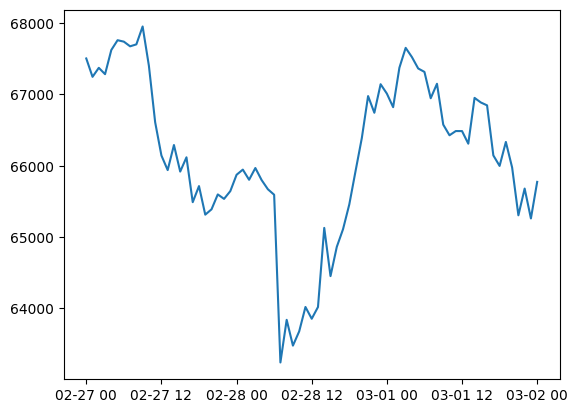

In [43]:
plt.plot(btc_iran.index, btc_iran["BTC"])

In [44]:
# ── MADURO WEEKEND: BTC vs XAUUSDT (normalised to 100) ────────────────────
from plotly.subplots import make_subplots

BTC_COLOR = "#F7931A"   # bitcoin orange

fig_maduro_btc = go.Figure()

# Hours from start for cleaner x-axis
hours_btc_m  = (btc_maduro_norm.index - btc_maduro_norm.index[0]).total_seconds() / 3600
hours_xau_m  = (xau_maduro_norm.index - xau_maduro_norm.index[0]).total_seconds() / 3600

fig_maduro_btc.add_trace(go.Scatter(
    x=btc_maduro_norm.index, y=btc_maduro_norm.values,
    name="BTC", mode="lines",
    line=dict(color=BTC_COLOR, width=2.5),
))
fig_maduro_btc.add_trace(go.Scatter(
    x=xau_maduro_norm.index, y=xau_maduro_norm.values,
    name="Bitget XAUUSDT", mode="lines",
    line=dict(color=BITGET_COLOR, width=2.5),
))

# Maduro event annotation
fig_maduro_btc.add_vline(
    x=maduro_announcement_time.timestamp() * 1000,
    line_width=1.5, line_dash="dash", line_color="red",
)
fig_maduro_btc.add_annotation(
    x=maduro_announcement_time,
    y=max(btc_maduro_norm.max(), xau_maduro_norm.max()) * 1.002,
    text="US Military Strike<br>in Venezuela",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="white", size=12),
    bgcolor="rgba(180,0,0,0.55)", bordercolor="red", borderwidth=1,
    ax=80, ay=-40,
)

# Shaded weekend closure
fig_maduro_btc.add_vrect(
    x0=maduro_trad_close, x1=maduro_trad_open,
    fillcolor="rgba(255,255,255,0.06)", line_width=0,
)
fig_maduro_btc.add_annotation(
    x=maduro_trad_close + (maduro_trad_open - maduro_trad_close) / 2,
    y=1.0, yref="paper",
    text="Traditional markets closed",
    showarrow=False,
    font=dict(color="rgba(255,255,255,0.5)", size=11),
)

update_timeseries_layout(fig_maduro_btc)
fig_maduro_btc.update_layout(
    yaxis_title="Indexed Price (100 = window start)",
    xaxis=dict(
        tickformat="%a %d %b\n%H:%M UTC",
        dtick=6 * 3600 * 1000,
    ),
)
add_watermark(fig_maduro_btc)
fig_maduro_btc

In [45]:
# ── IRAN WEEKEND: BTC vs XAUUSDT (normalised to 100) ─────────────────────

fig_iran_btc = go.Figure()

fig_iran_btc.add_trace(go.Scatter(
    x=btc_iran_norm.index, y=btc_iran_norm.values,
    name="BTC", mode="lines",
    line=dict(color=BTC_COLOR, width=2.5),
))
fig_iran_btc.add_trace(go.Scatter(
    x=xau_iran_norm.index, y=xau_iran_norm.values,
    name="Bitget XAUUSDT", mode="lines",
    line=dict(color=BITGET_COLOR, width=2.5),
))

# Iran event annotation
fig_iran_btc.add_vline(
    x=announcement_time.timestamp() * 1000,
    line_width=1.5, line_dash="dash", line_color="red",
)
fig_iran_btc.add_annotation(
    x=announcement_time,
    y=max(btc_iran_norm.max(), xau_iran_norm.max()) * 1.002,
    text="Trump announces<br>Iran airstrikes",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="white", size=12),
    bgcolor="rgba(180,0,0,0.55)", bordercolor="red", borderwidth=1,
    ax=80, ay=-40,
)

# Shaded weekend closure
fig_iran_btc.add_vrect(
    x0=trad_close, x1=trad_open,
    fillcolor="rgba(255,255,255,0.06)", line_width=0,
)
fig_iran_btc.add_annotation(
    x=trad_close + (trad_open - trad_close) / 2,
    y=1.0, yref="paper",
    text="Traditional markets closed",
    showarrow=False,
    font=dict(color="rgba(255,255,255,0.5)", size=11),
)

update_timeseries_layout(fig_iran_btc)
fig_iran_btc.update_layout(
    yaxis_title="Indexed Price (100 = window start)",
    xaxis=dict(
        tickformat="%a %d %b\n%H:%M UTC",
        dtick=6 * 3600 * 1000,
    ),
)
add_watermark(fig_iran_btc)
fig_iran_btc

In [ ]:
# ── Side-by-side summary: how did BTC vs Gold behave in each event? ───────

# Maduro: measure from announcement to peak within 24h
maduro_ann = maduro_announcement_time  # 2026-01-03 06:01 UTC
btc_at_maduro_ann     = btc.loc[:maduro_ann].iloc[-1]["BTC"]
btc_24h_after_maduro  = btc.loc[maduro_ann:maduro_ann + pd.Timedelta(hours=24)]
btc_peak_maduro       = btc_24h_after_maduro["BTC"].max()
btc_peak_maduro_time  = btc_24h_after_maduro["BTC"].idxmax()

xau_at_maduro_ann     = xau_maduro.loc[:maduro_ann].iloc[-1]["Bitget XAUUSDT"]
xau_24h_after_maduro  = xau_maduro.loc[maduro_ann:maduro_ann + pd.Timedelta(hours=24)]
xau_peak_maduro       = xau_24h_after_maduro["Bitget XAUUSDT"].max()
xau_peak_maduro_time  = xau_24h_after_maduro["Bitget XAUUSDT"].idxmax()

# Iran: measure from announcement to peak within 24h
iran_ann = announcement_time  # 2026-02-28 07:30 UTC
btc_at_iran_ann     = btc.loc[:iran_ann].iloc[-1]["BTC"]
btc_24h_after_iran  = btc.loc[iran_ann:iran_ann + pd.Timedelta(hours=24)]
btc_peak_iran       = btc_24h_after_iran["BTC"].max()
btc_low_iran        = btc_24h_after_iran["BTC"].min()
btc_low_iran_time   = btc_24h_after_iran["BTC"].idxmin()

xau_at_iran_ann     = bitget_xau.loc[:iran_ann].iloc[-1]["Bitget XAUUSDT"]
xau_24h_after_iran  = bitget_xau.loc[iran_ann:iran_ann + pd.Timedelta(hours=24)]
xau_peak_iran       = xau_24h_after_iran["Bitget XAUUSDT"].max()
xau_peak_iran_time  = xau_24h_after_iran["Bitget XAUUSDT"].idxmax()

print("=" * 70)
print("         MADURO (Sat 3 Jan)          vs   IRAN (Sat 28 Feb)")
print("=" * 70)
print()
print("BTC reaction (24h post-event):")
print(f"  Maduro:  ${btc_at_maduro_ann:,.0f} → ${btc_peak_maduro:,.0f}  ({(btc_peak_maduro/btc_at_maduro_ann-1)*100:+.2f}%  RALLY)")
print(f"  Iran:    ${btc_at_iran_ann:,.0f} → ${btc_low_iran:,.0f}  ({(btc_low_iran/btc_at_iran_ann-1)*100:+.2f}%  SELL-OFF)")
print()
print("Bitget XAUUSDT reaction (24h post-event):")
print(f"  Maduro:  ${xau_at_maduro_ann:,.2f} → ${xau_peak_maduro:,.2f}  ({(xau_peak_maduro/xau_at_maduro_ann-1)*100:+.2f}%)")
print(f"  Iran:    ${xau_at_iran_ann:,.2f} → ${xau_peak_iran:,.2f}  ({(xau_peak_iran/xau_at_iran_ann-1)*100:+.2f}%)")
print()
print("─" * 70)
print("INTERPRETATION:")
print("  • Maduro:  BTC and gold BOTH rallied → crypto used as a safe-haven")
print("             proxy / hedge alongside gold")
print("  • Iran:    Gold rallied but BTC sold off → traders went DIRECT to")
print("             the tokenised gold perp rather than hedging via BTC")
print("─" * 70) #disagree with copilot interp here

         MADURO (Sat 3 Jan)          vs   IRAN (Sat 28 Feb)

BTC reaction (24h post-event):
  Maduro:  $90,006 → $91,441  (+1.59%  RALLY)
  Iran:    $63,239 → $63,475  (+0.37%  SELL-OFF)

Bitget XAUUSDT reaction (24h post-event):
  Maduro:  $4,339.91 → $4,361.43  (+0.50%)
  Iran:    $5,308.87 → $5,402.00  (+1.75%)

──────────────────────────────────────────────────────────────────────
INTERPRETATION:
  • Maduro:  BTC and gold BOTH rallied → crypto used as a safe-haven
             proxy / hedge alongside gold
  • Iran:    Gold rallied but BTC sold off → traders went DIRECT to
             the tokenised gold perp rather than hedging via BTC
──────────────────────────────────────────────────────────────────────


In [47]:
from pathlib import Path
import pandas as pd

data_dir = Path("data")

# pick latest outputs from the script
raw_path = sorted(data_dir.glob("bitget_xau_xag_volume_raw_*.csv"))[-1]
hourly_path = sorted(data_dir.glob("bitget_xau_xag_volume_hourly_*.csv"))[-1]
summary_path = sorted(data_dir.glob("bitget_xau_xag_volume_summary_*.csv"))[-1]

raw_vol_df = pd.read_csv(raw_path, parse_dates=["datetime_utc"])
hourly_vol_df = pd.read_csv(hourly_path, parse_dates=["hour_utc"])
summary_vol_df = pd.read_csv(summary_path)

print("Raw:", raw_path.name, raw_vol_df.shape)
print("Hourly:", hourly_path.name, hourly_vol_df.shape)
print("Summary:", summary_path.name, summary_vol_df.shape)

summary_vol_df

Raw: bitget_xau_xag_volume_raw_20260228T073000Z.csv (34392, 12)
Hourly: bitget_xau_xag_volume_hourly_20260228T073000Z.csv (580, 9)
Summary: bitget_xau_xag_volume_summary_20260228T073000Z.csv (12, 10)


,venue,product_type,symbol,phase,rows,total_usdt_volume,mean_usdt_volume_per_bar,total_base_volume,mean_base_volume_per_bar,event_vs_pre_usdt_vol_ratio
0,futures,USDT-FUTURES,BTCUSDT,event_window,358,8.457823e+08,2.362520e+06,1.325273e+04,37.018801,0.808058
1,futures,USDT-FUTURES,BTCUSDT,post_window,3941,1.100424e+10,2.792246e+06,1.643668e+05,41.706885,0.808058
2,futures,USDT-FUTURES,BTCUSDT,pre_window,4299,1.256900e+10,2.923703e+06,1.879462e+05,43.718597,0.808058
3,futures,USDT-FUTURES,XAGUSDT,event_window,358,4.717537e+07,1.317748e+05,4.985524e+05,1392.604469,0.977103
4,futures,USDT-FUTURES,XAGUSDT,post_window,3941,4.836539e+08,1.227236e+05,5.260737e+06,1334.873608,0.977103
5,futures,USDT-FUTURES,XAGUSDT,pre_window,4299,5.797752e+08,1.348628e+05,6.431958e+06,1496.152182,0.977103
6,futures,USDT-FUTURES,XAUUSDT,event_window,358,1.171152e+08,3.271373e+05,2.193925e+04,61.282821,3.665494
7,futures,USDT-FUTURES,XAUUSDT,post_window,3941,4.944998e+08,1.254757e+05,9.265346e+04,23.510140,3.665494
8,futures,USDT-FUTURES,XAUUSDT,pre_window,4299,3.836764e+08,8.924782e+04,7.370058e+04,17.143657,3.665494
9,spot,SPOT,BTCUSDT,event_window,358,9.492021e+07,2.651402e+05,1.487220e+03,4.154246,0.774045


In [48]:
hourly_vol_df

,venue,product_type,symbol,hour_utc,bars,close,total_usdt_volume,total_base_volume,total_quote_volume
0,futures,USDT-FUTURES,BTCUSDT,2026-02-25 07:00:00+00:00,30,65008.00,3.429070e+07,527.733000,3.429070e+07
1,futures,USDT-FUTURES,BTCUSDT,2026-02-25 08:00:00+00:00,60,65487.60,1.174118e+08,1797.877800,1.174118e+08
2,futures,USDT-FUTURES,BTCUSDT,2026-02-25 09:00:00+00:00,60,65519.30,9.337867e+07,1425.446400,9.337867e+07
3,futures,USDT-FUTURES,BTCUSDT,2026-02-25 10:00:00+00:00,59,65368.80,6.520535e+07,996.766400,6.520535e+07
4,futures,USDT-FUTURES,BTCUSDT,2026-02-25 11:00:00+00:00,60,65395.90,7.730196e+07,1184.012700,7.730196e+07
...,...,...,...,...,...,...,...,...,...
575,spot,SPOT,BTCUSDT,2026-03-03 03:00:00+00:00,60,68371.14,7.204019e+06,105.358466,7.204019e+06
576,spot,SPOT,BTCUSDT,2026-03-03 04:00:00+00:00,59,68125.51,5.374713e+06,78.737669,5.374713e+06
577,spot,SPOT,BTCUSDT,2026-03-03 05:00:00+00:00,60,67943.31,1.183270e+07,173.479173,1.183270e+07
578,spot,SPOT,BTCUSDT,2026-03-03 06:00:00+00:00,60,68104.89,9.463540e+06,139.205774,9.463540e+06


In [54]:
announcement_time = pd.Timestamp("2026-02-28 07:30", tz="UTC")
trad_close = pd.Timestamp("2026-02-27 22:00", tz="UTC")
trad_open  = pd.Timestamp("2026-03-01 23:00", tz="UTC")

# raw_vol_df from your script output
vol = raw_vol_df[
    (raw_vol_df["venue"] == "futures")
    & (raw_vol_df["product_type"] == "USDT-FUTURES")
    & (raw_vol_df["symbol"].isin(["XAUUSDT", "XAGUSDT"]))
].copy()

# pivot at native 1m frequency (as pulled)
plot_vol = (
    vol.pivot_table(index="datetime_utc", columns="symbol", values="usdt_volume", aggfunc="sum")
       .sort_index()
)

# Use the full 3-day-before / 3-day-after range from the script
# (don't clip like the price charts — the contrast with normal weekday volume is the point)
plot_vol = plot_vol.dropna(how="all")

XAU_VOL_COLOR = "gold"
XAG_VOL_COLOR = "#FFFFFF"

fig_vol = go.Figure()

fig_vol.add_trace(go.Scatter(
    x=plot_vol.index,
    y=plot_vol["XAUUSDT"],
    name="XAUUSDT Perp Volume",
    mode="lines",
    line=dict(color=XAU_VOL_COLOR, width=2.2),
    connectgaps=False,
))

fig_vol.add_trace(go.Scatter(
    x=plot_vol.index,
    y=plot_vol["XAGUSDT"],
    name="XAGUSDT Perp Volume",
    mode="lines",
    line=dict(color=XAG_VOL_COLOR, width=1.8),
    connectgaps=False,
))

fig_vol.add_vline(
    x=announcement_time.timestamp() * 1000,
    line_width=1.5, line_dash="dash", line_color="white",
)
fig_vol.add_annotation(
    x=announcement_time,
    y=plot_vol[["XAUUSDT", "XAGUSDT"]].max().max() * 1.02,
    text="Trump announces<br>Iran airstrikes<br>Sat 28 Feb 07:30 UTC",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="white", size=12),
    bgcolor="rgba(180,0,0,0.55)",
    bordercolor="red",
    borderwidth=1,
    ax=80, ay=-40,
)

fig_vol.add_vrect(
    x0=trad_close, x1=trad_open,
    fillcolor="rgba(255,255,255,0.06)",
    line_width=0,
)
fig_vol.add_annotation(
    x=trad_close + (trad_open - trad_close) / 1.3,
    y=1.0, yref="paper",
    text="Traditional markets closed",
    showarrow=False,
    font=dict(color="white", size=11),
)

update_timeseries_layout(fig_vol)
fig_vol.update_layout(
    yaxis_title="Minutely USDT Volume",
    yaxis_tickprefix="$",
    xaxis=dict(
        tickformat="%a %d %b\n%H:%M UTC",
        dtick=6 * 3600 * 1000,
    ),
)

add_watermark(fig_vol)
fig_vol


In [61]:
# ══════════════════════════════════════════════════════════════════════════
# BTC vs XAU VOLUME COMPARISON — Iran vs Maduro
# ══════════════════════════════════════════════════════════════════════════

from pathlib import Path

data_dir = Path("data")

# ── Load Iran event volumes (includes BTC + XAU + XAG) ───────────────────
iran_raw = pd.read_csv(
    data_dir / "bitget_xau_xag_volume_raw_20260228T073000Z.csv", #minutely volume data for XAU and XAG USDT around Iran
    parse_dates=["datetime_utc"],
)
iran_summary = pd.read_csv(
    data_dir / "bitget_xau_xag_volume_summary_20260228T073000Z.csv",
)

# ── Load Maduro event volumes (BTC + XAU; XAG not listed yet) ────────────
maduro_raw = pd.read_csv(
    data_dir / "bitget_xau_xag_volume_raw_20260103T060100Z.csv",
    parse_dates=["datetime_utc"],
)
maduro_summary = pd.read_csv(
    data_dir / "bitget_xau_xag_volume_summary_20260103T060100Z.csv", ##minutely volume data for XAU and XAG USDT around Maduro
)

In [ ]:
# ── IRAN WEEKEND: BTC vs XAUUSDT Perp Futures USDT Volume (hourly) ─────────────

BTC_COLOR  = "#F7931A"
BITGET_COLOR = "#00E5A0"

# Filter futures only, resample to hourly for cleaner visual
iran_fut = iran_raw[
    (iran_raw["venue"] == "futures")
    & (iran_raw["product_type"] == "USDT-FUTURES")
    & (iran_raw["symbol"].isin(["BTCUSDT", "XAUUSDT"]))
].copy()

iran_hourly = (
    iran_fut.set_index("datetime_utc")
    .groupby("symbol")["usdt_volume"]
    .resample("1h").sum()
    .reset_index()
    .pivot(index="datetime_utc", columns="symbol", values="usdt_volume")
    .sort_index()
)

announcement_time = pd.Timestamp("2026-02-28 07:30", tz="UTC")
trad_close = pd.Timestamp("2026-02-27 22:00", tz="UTC")
trad_open  = pd.Timestamp("2026-03-01 23:00", tz="UTC")

from plotly.subplots import make_subplots

fig_iran_vol = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=("XAUUSDT Futures — Hourly USDT Volume", "BTCUSDT Futures — Hourly USDT Volume"),
)

fig_iran_vol.add_trace(go.Bar(
    x=iran_hourly.index, y=iran_hourly["XAUUSDT"],
    name="XAUUSDT", marker_color=BITGET_COLOR, opacity=0.85,
), row=1, col=1)

fig_iran_vol.add_trace(go.Bar(
    x=iran_hourly.index, y=iran_hourly["BTCUSDT"],
    name="BTCUSDT", marker_color=BTC_COLOR, opacity=0.85,
), row=2, col=1)

# Annotations on both subplots
for row in [1, 2]:
    fig_iran_vol.add_vline(
        x=announcement_time.timestamp() * 1000,
        line_width=1.5, line_dash="dash", line_color="red",
        row=row, col=1,
    )
    fig_iran_vol.add_vrect(
        x0=trad_close, x1=trad_open,
        fillcolor="rgba(255,255,255,0.06)", line_width=0,
        row=row, col=1,
    )

fig_iran_vol.add_annotation(
    x=announcement_time, y=iran_hourly["XAUUSDT"].max() * 1.05,
    text="Iran airstrikes<br>announced",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="white", size=11),
    bgcolor="rgba(180,0,0,0.55)", bordercolor="red", borderwidth=1,
    ax=70, ay=-30, row=1, col=1,
)

update_timeseries_layout(fig_iran_vol)
fig_iran_vol.update_layout(
    height=750,
    yaxis_tickprefix="$", yaxis2_tickprefix="$",
    xaxis2=dict(tickformat="%a %d %b\n%H:%M UTC", dtick=12 * 3600 * 1000),
)
fig_iran_vol.update_annotations(font=dict(color="white"))

add_watermark(fig_iran_vol)
fig_iran_vol

In [62]:
# ── MADURO WEEKEND: BTC vs XAUUSDT Futures USDT Volume (hourly) ───────────

maduro_fut = maduro_raw[
    (maduro_raw["venue"] == "futures")
    & (maduro_raw["product_type"] == "USDT-FUTURES")
    & (maduro_raw["symbol"].isin(["BTCUSDT", "XAUUSDT"]))
].copy()

maduro_hourly_vol = (
    maduro_fut.set_index("datetime_utc")
    .groupby("symbol")["usdt_volume"]
    .resample("1h").sum()
    .reset_index()
    .pivot(index="datetime_utc", columns="symbol", values="usdt_volume")
    .sort_index()
)

maduro_announcement_time = pd.Timestamp("2026-01-03 06:01", tz="UTC")
maduro_trad_close = pd.Timestamp("2026-01-02 22:00", tz="UTC")
maduro_trad_open  = pd.Timestamp("2026-01-04 23:00", tz="UTC")

fig_maduro_vol = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=("XAUUSDT Futures — Hourly USDT Volume", "BTCUSDT Futures — Hourly USDT Volume"),
)

fig_maduro_vol.add_trace(go.Bar(
    x=maduro_hourly_vol.index, y=maduro_hourly_vol["XAUUSDT"],
    name="XAUUSDT", marker_color=BITGET_COLOR, opacity=0.85,
), row=1, col=1)

fig_maduro_vol.add_trace(go.Bar(
    x=maduro_hourly_vol.index, y=maduro_hourly_vol["BTCUSDT"],
    name="BTCUSDT", marker_color=BTC_COLOR, opacity=0.85,
), row=2, col=1)

for row in [1, 2]:
    fig_maduro_vol.add_vline(
        x=maduro_announcement_time.timestamp() * 1000,
        line_width=1.5, line_dash="dash", line_color="red",
        row=row, col=1,
    )
    fig_maduro_vol.add_vrect(
        x0=maduro_trad_close, x1=maduro_trad_open,
        fillcolor="rgba(255,255,255,0.06)", line_width=0,
        row=row, col=1,
    )

fig_maduro_vol.add_annotation(
    x=maduro_announcement_time, y=maduro_hourly_vol["XAUUSDT"].max() * 1.05,
    text="Venezuela strike<br>announced",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="white", size=11),
    bgcolor="rgba(180,0,0,0.55)", bordercolor="red", borderwidth=1,
    ax=70, ay=-30, row=1, col=1,
)

update_timeseries_layout(fig_maduro_vol)
fig_maduro_vol.update_layout(
    height=750,
    yaxis_tickprefix="$", yaxis2_tickprefix="$",
    xaxis2=dict(tickformat="%a %d %b\n%H:%M UTC", dtick=12 * 3600 * 1000),
)
fig_maduro_vol.update_annotations(font=dict(color="white"))

add_watermark(fig_maduro_vol)
fig_maduro_vol

In [63]:
# ── Volume ratio comparison table ─────────────────────────────────────────

# Build a clean comparison of event-vs-pre volume ratios
def extract_ratios(summary_df, event_label):
    """Pull unique (venue, product_type, symbol, ratio) from a summary CSV."""
    cols = ["venue", "product_type", "symbol", "event_vs_pre_usdt_vol_ratio"]
    return (
        summary_df[cols]
        .drop_duplicates()
        .assign(event=event_label)
    )

ratios = pd.concat([
    extract_ratios(iran_summary, "Iran (28 Feb)"),
    extract_ratios(maduro_summary, "Maduro (3 Jan)"),
], ignore_index=True)

# Pivot for display
ratio_table = ratios.pivot_table(
    index=["venue", "product_type", "symbol"],
    columns="event",
    values="event_vs_pre_usdt_vol_ratio",
)
ratio_table.columns.name = None
ratio_table = ratio_table.round(2)

print("=" * 60)
print("  EVENT vs PRE-WINDOW VOLUME RATIOS (mean USDT vol/bar)")
print("=" * 60)
print(ratio_table.to_string())
print()
print("─" * 60)
print("READING THE TABLE:")
print("  >1.0 = volume INCREASED during event vs normal")
print("  <1.0 = volume DECREASED during event vs normal")
print()
print("IRAN (Feb):  XAUUSDT 3.67x ↑↑↑  |  BTCUSDT futures 0.81x ↓  |  BTC spot 0.77x ↓")
print("  → Traders piled into gold, AVOIDED BTC")
print()
print("MADURO (Jan): BTC spot 1.25x ↑  |  XAUUSDT 1.13x ↑  |  BTCUSDT futures 0.88x ↓")
print("  → Traders used BTC spot as primary hedge alongside gold")
print("─" * 60)

  EVENT vs PRE-WINDOW VOLUME RATIOS (mean USDT vol/bar)
                              Iran (28 Feb)  Maduro (3 Jan)
venue   product_type symbol                                
futures USDT-FUTURES BTCUSDT           0.81            0.88
                     XAGUSDT           0.98             NaN
                     XAUUSDT           3.67            1.13
spot    SPOT         BTCUSDT           0.77            1.25

────────────────────────────────────────────────────────────
READING THE TABLE:
  >1.0 = volume INCREASED during event vs normal
  <1.0 = volume DECREASED during event vs normal

IRAN (Feb):  XAUUSDT 3.67x ↑↑↑  |  BTCUSDT futures 0.81x ↓  |  BTC spot 0.77x ↓
  → Traders piled into gold, AVOIDED BTC

MADURO (Jan): BTC spot 1.25x ↑  |  XAUUSDT 1.13x ↑  |  BTCUSDT futures 0.88x ↓
  → Traders used BTC spot as primary hedge alongside gold
────────────────────────────────────────────────────────────


In [64]:
# ── IRAN WEEKEND: BTC Spot vs XAUUSDT Futures Volume (hourly) ─────────────

# BTC spot volume for Iran
iran_spot_btc = iran_raw[
    (iran_raw["venue"] == "spot") & (iran_raw["symbol"] == "BTCUSDT")
].copy()
iran_fut_xau = iran_raw[
    (iran_raw["venue"] == "futures") & (iran_raw["symbol"] == "XAUUSDT")
].copy()

iran_spot_hourly = (
    pd.concat([iran_spot_btc, iran_fut_xau])
    .set_index("datetime_utc")
    .groupby("symbol")["usdt_volume"]
    .resample("1h").sum()
    .reset_index()
    .pivot(index="datetime_utc", columns="symbol", values="usdt_volume")
    .sort_index()
)

fig_iran_spot = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=("XAUUSDT Futures — Hourly USDT Volume", "BTCUSDT Spot — Hourly USDT Volume"),
)

fig_iran_spot.add_trace(go.Bar(
    x=iran_spot_hourly.index, y=iran_spot_hourly["XAUUSDT"],
    name="XAUUSDT Futures", marker_color=BITGET_COLOR, opacity=0.85,
), row=1, col=1)

fig_iran_spot.add_trace(go.Bar(
    x=iran_spot_hourly.index, y=iran_spot_hourly["BTCUSDT"],
    name="BTCUSDT Spot", marker_color=BTC_COLOR, opacity=0.85,
), row=2, col=1)

for row in [1, 2]:
    fig_iran_spot.add_vline(
        x=announcement_time.timestamp() * 1000,
        line_width=1.5, line_dash="dash", line_color="red",
        row=row, col=1,
    )
    fig_iran_spot.add_vrect(
        x0=trad_close, x1=trad_open,
        fillcolor="rgba(255,255,255,0.06)", line_width=0,
        row=row, col=1,
    )

fig_iran_spot.add_annotation(
    x=announcement_time, y=iran_spot_hourly["XAUUSDT"].max() * 1.05,
    text="Iran airstrikes<br>announced",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="white", size=11),
    bgcolor="rgba(180,0,0,0.55)", bordercolor="red", borderwidth=1,
    ax=70, ay=-30, row=1, col=1,
)

update_timeseries_layout(fig_iran_spot)
fig_iran_spot.update_layout(
    height=750,
    yaxis_tickprefix="$", yaxis2_tickprefix="$",
    xaxis2=dict(tickformat="%a %d %b\n%H:%M UTC", dtick=12 * 3600 * 1000),
)
fig_iran_spot.update_annotations(font=dict(color="white"))
add_watermark(fig_iran_spot)
fig_iran_spot

In [65]:
# ── MADURO WEEKEND: BTC Spot vs XAUUSDT Futures Volume (hourly) ───────────

maduro_announcement_time = pd.Timestamp("2026-01-03 06:01", tz="UTC")
maduro_trad_close = pd.Timestamp("2026-01-02 22:00", tz="UTC")
maduro_trad_open  = pd.Timestamp("2026-01-04 23:00", tz="UTC")

maduro_spot_btc = maduro_raw[
    (maduro_raw["venue"] == "spot") & (maduro_raw["symbol"] == "BTCUSDT")
].copy()
maduro_fut_xau = maduro_raw[
    (maduro_raw["venue"] == "futures") & (maduro_raw["symbol"] == "XAUUSDT")
].copy()

maduro_spot_hourly = (
    pd.concat([maduro_spot_btc, maduro_fut_xau])
    .set_index("datetime_utc")
    .groupby("symbol")["usdt_volume"]
    .resample("1h").sum()
    .reset_index()
    .pivot(index="datetime_utc", columns="symbol", values="usdt_volume")
    .sort_index()
)

fig_maduro_spot = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=("XAUUSDT Futures — Hourly USDT Volume", "BTCUSDT Spot — Hourly USDT Volume"),
)

fig_maduro_spot.add_trace(go.Bar(
    x=maduro_spot_hourly.index, y=maduro_spot_hourly["XAUUSDT"],
    name="XAUUSDT Futures", marker_color=BITGET_COLOR, opacity=0.85,
), row=1, col=1)

fig_maduro_spot.add_trace(go.Bar(
    x=maduro_spot_hourly.index, y=maduro_spot_hourly["BTCUSDT"],
    name="BTCUSDT Spot", marker_color=BTC_COLOR, opacity=0.85,
), row=2, col=1)

for row in [1, 2]:
    fig_maduro_spot.add_vline(
        x=maduro_announcement_time.timestamp() * 1000,
        line_width=1.5, line_dash="dash", line_color="red",
        row=row, col=1,
    )
    fig_maduro_spot.add_vrect(
        x0=maduro_trad_close, x1=maduro_trad_open,
        fillcolor="rgba(255,255,255,0.06)", line_width=0,
        row=row, col=1,
    )

fig_maduro_spot.add_annotation(
    x=maduro_announcement_time, y=maduro_spot_hourly["XAUUSDT"].max() * 1.05,
    text="Venezuela strike<br>announced",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="white", size=11),
    bgcolor="rgba(180,0,0,0.55)", bordercolor="red", borderwidth=1,
    ax=70, ay=-30, row=1, col=1,
)

update_timeseries_layout(fig_maduro_spot)
fig_maduro_spot.update_layout(
    height=750,
    yaxis_tickprefix="$", yaxis2_tickprefix="$",
    xaxis2=dict(tickformat="%a %d %b\n%H:%M UTC", dtick=12 * 3600 * 1000),
)
fig_maduro_spot.update_annotations(font=dict(color="white"))
add_watermark(fig_maduro_spot)
fig_maduro_spot